In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler, StandardScaler, QuantileTransformer


In [9]:
df5k_v0 = pd.read_csv('~/Documents/datacamp/WBS-School/moosic/df_audio_features_5000.csv')

# df5k.info()
df5k = df5k_v0.copy()

In [10]:
# remove whitespace from column labels
df5k.columns = df5k.columns.str.replace(' ', '')
df5k_v0.columns = df5k_v0.columns.str.replace(' ', '')



In [11]:
feature_ls = ['danceability','speechiness','energy','valence','liveness','acousticness','instrumentalness','tempo','duration_ms','cluster']
drop_ls = [x for x in df5k.columns if x not in feature_ls]
print(drop_ls)
df5k.drop(drop_ls, axis=1, inplace=True)
# df5k.drop(['name','artist','mode','type','id','html'], axis=1, inplace=True)
df5k

['name', 'artist', 'key', 'loudness', 'mode', 'type', 'time_signature', 'id', 'html']


,danceability,energy,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,0.6580,0.25900,0.0705,0.694,0.000059,0.9750,0.3060,110.376,256213
1,0.7420,0.39900,0.0346,0.217,0.000002,0.1070,0.6930,125.039,191867
2,0.8510,0.73000,0.3470,0.453,0.000063,0.1240,0.9050,93.698,152267
3,0.7050,0.05020,0.0471,0.879,0.000041,0.3860,0.5240,106.802,186227
4,0.6510,0.11900,0.0380,0.916,0.000343,0.1040,0.4020,120.941,273680
...,...,...,...,...,...,...,...,...,...
5230,0.2020,0.06940,0.0473,0.917,0.715000,0.0832,0.0655,87.906,995000
5231,0.1880,0.10100,0.0442,0.855,0.426000,0.0694,0.0355,83.134,855000
5232,0.0596,0.00093,0.0434,0.951,0.969000,0.0772,0.0344,71.573,238187
5233,0.1330,0.02080,0.0419,0.883,0.505000,0.1110,0.0591,67.109,314307


In [13]:
# scaling
# minmax provides distinct groups per 1k sample
minmax_scaled5k = MinMaxScaler().fit_transform(df5k)

# try other scaling method (quantile)

In [14]:
# use elbow method to find optimal inertia

inertia_keys = list(range(1, 30))
inertia_list = []
for c in range(1,30):
    km = KMeans(n_clusters=c)
    km.fit(minmax_scaled5k)
    inertia_list.append(round(km.inertia_))
inertia_dc = dict(zip(inertia_keys,inertia_list))
print(inertia_dc)

{1: 2779, 2: 1834, 3: 1235, 4: 984, 5: 798, 6: 734, 7: 685, 8: 651, 9: 619, 10: 596, 11: 575, 12: 558, 13: 538, 14: 524, 15: 512, 16: 499, 17: 488, 18: 478, 19: 471, 20: 460, 21: 451, 22: 441, 23: 434, 24: 429, 25: 422, 26: 415, 27: 410, 28: 406, 29: 398}


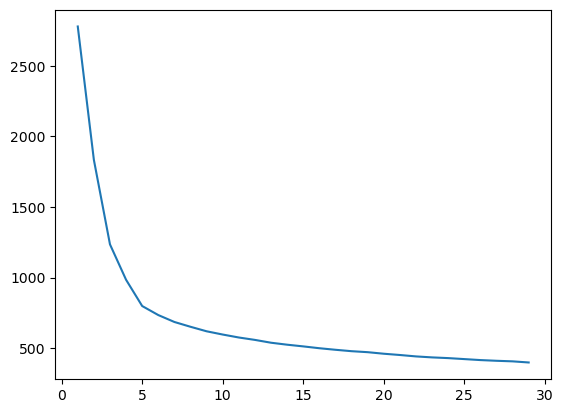

In [17]:
# elbow plot
# observation: k = 4
plt.plot(inertia_keys, inertia_list)
plt.show()

In [18]:
# generate model
clusters = 5
km = KMeans(n_clusters=clusters)
km.fit(df5k)
clust_se = km.predict(df5k)
df5k['cluster'] = clust_se
# display(df5k.head(5))

In [19]:
df5k.max()['cluster'] # max cluster numbers

4.0

In [20]:
# cluster exploration
df5k.columns.values
dims = list(df5k.columns.values)
print(dims)
dimension = dims[1]

['danceability', 'energy', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms', 'cluster']


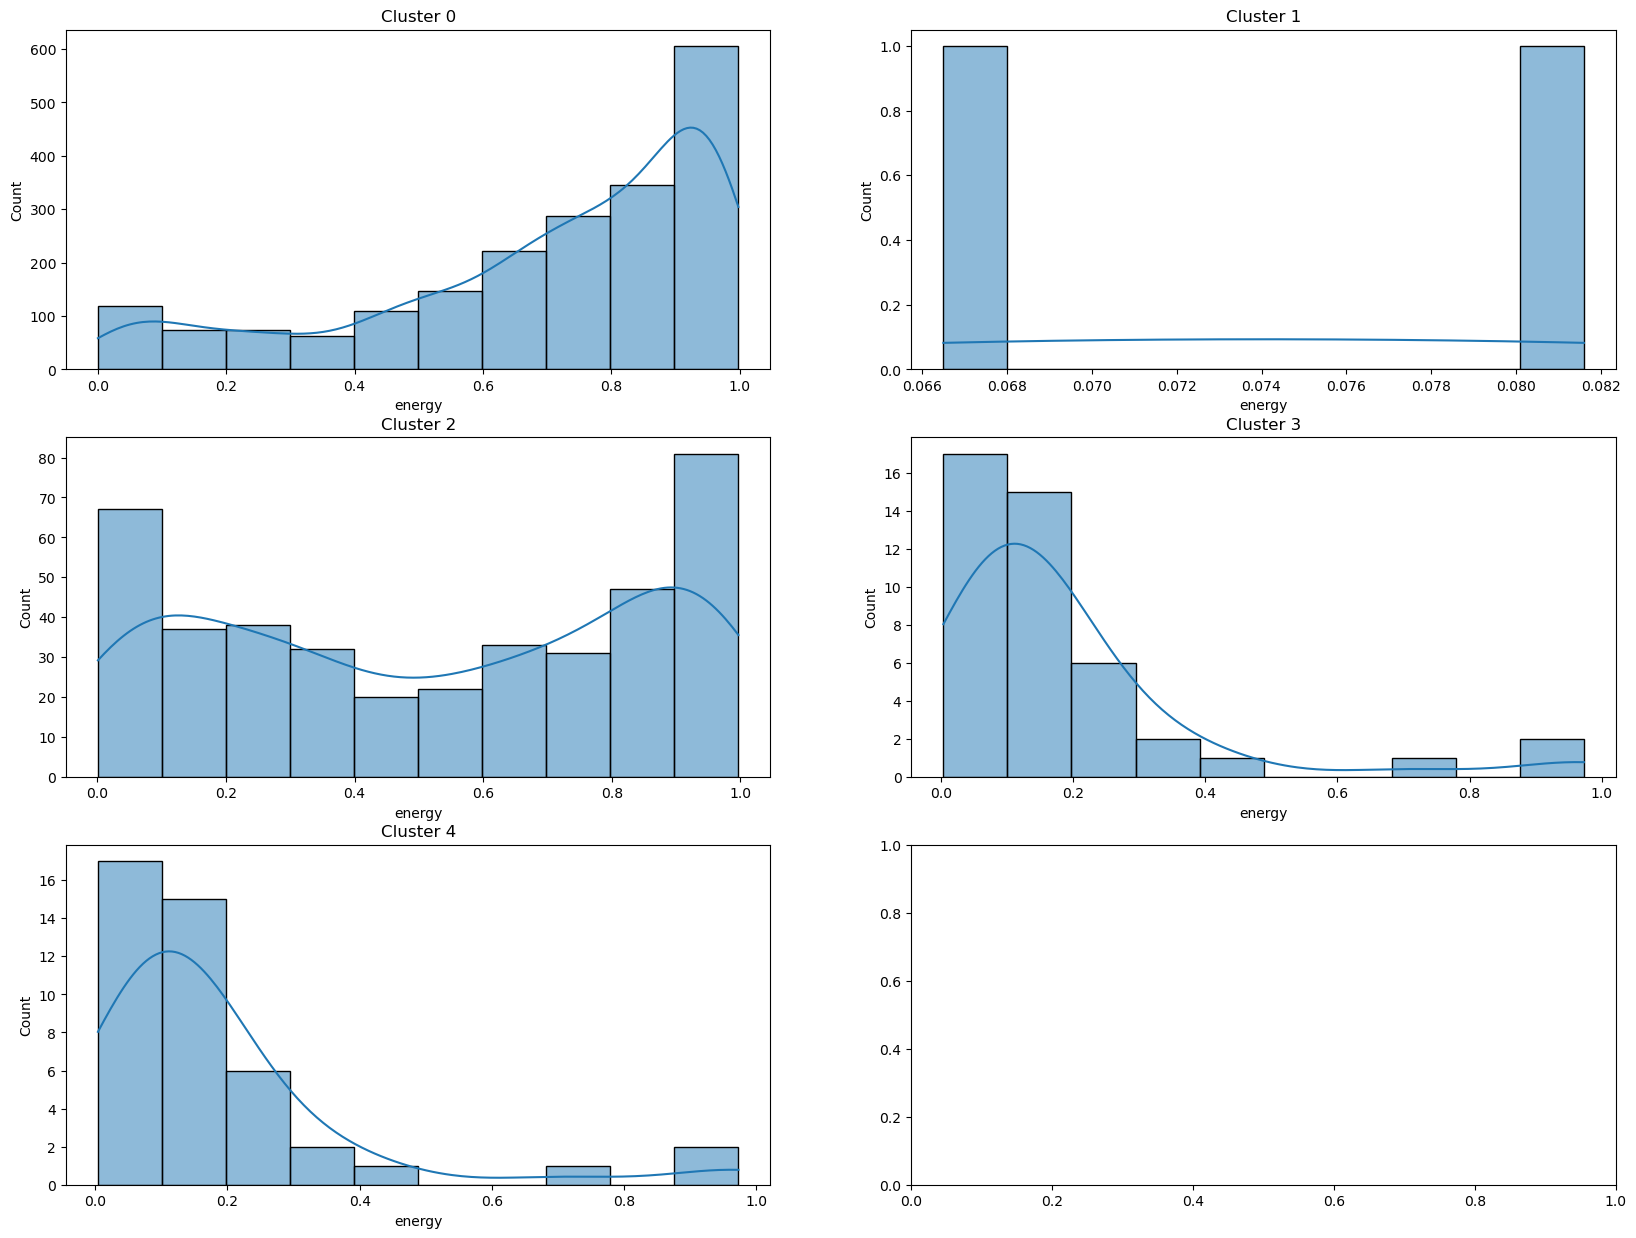

In [23]:


fig, ax = plt.subplots(3, 2, figsize=(20, 15))

# dimension distribution per cluster
c0 = df5k.loc[df5k['cluster']==0][dimension]
c1 = df5k.loc[df5k['cluster']==1][dimension]
c2 = df5k.loc[df5k['cluster']==2][dimension]
c3 = df5k.loc[df5k['cluster']==3][dimension]
c3 = df5k.loc[df5k['cluster']==4][dimension]

sns.histplot(data=c0, bins=10, kde=True,ax=ax[0,0])
sns.histplot(data=c1, bins=10, kde=True,ax=ax[0,1])
sns.histplot(data=c2, bins=10, kde=True,ax=ax[1,0])
sns.histplot(data=c3, bins=10, kde=True,ax=ax[1,1])
sns.histplot(data=c3, bins=10, kde=True,ax=ax[2,0])

# Adding titles to the plots
ax[0,0].set_title('Cluster 0')
ax[0,1].set_title('Cluster 1')
ax[1,0].set_title('Cluster 2')
ax[1,1].set_title('Cluster 3')
ax[2,0].set_title('Cluster 4')


plt.show()

/Users/cytalladen/opt/anaconda3/lib/python3.9/site-packages/seaborn/categorical.py:1296: UserWarning: 74.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/cytalladen/opt/anaconda3/lib/python3.9/site-packages/seaborn/categorical.py:1296: UserWarning: 13.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/cytalladen/opt/anaconda3/lib/python3.9/site-packages/seaborn/categorical.py:1296: UserWarning: 79.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


<AxesSubplot:xlabel='cluster', ylabel='energy'>

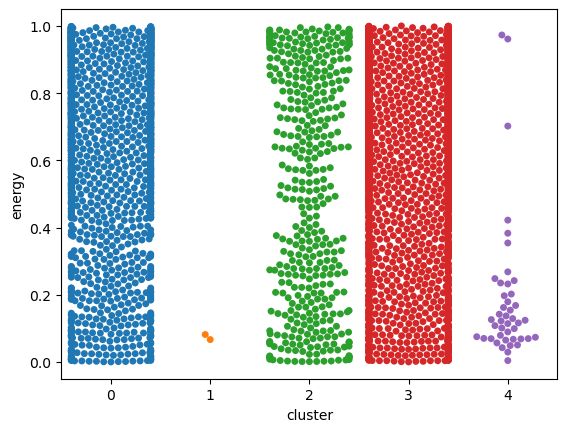

In [24]:
# cluster size plot
sns.swarmplot(x=df5k.cluster,y=df5k[dimension])

In [25]:
# labeling df with song names
df5k_v0['cluster'] = df5k['cluster']


/var/folders/qk/tw9hw7y536n3q312492k3k3m0000gn/T/ipykernel_98591/2151720479.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  to_plot['cluster'] = df5k['cluster']


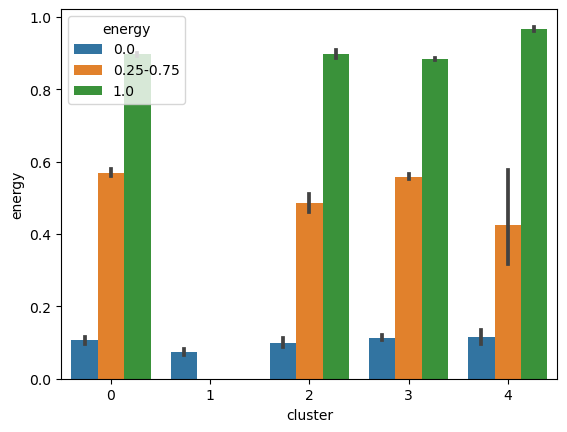

In [27]:
# plotting subgroups
# https://stackoverflow.com/questions/65119003/binning-pandas-value-counts
max = df5k_v0[dimension].max()
q3 = df5k_v0[dimension].max() * .75
q2 = df5k_v0[dimension].max() * .25
min = df5k_v0[dimension].min()
# bin_ls = list(df5k_v0[dimension].value_counts(bins = [min,q2,q3,max], sort = False)))
# print(df5k_v0[dimension])
# prop_df = df5k_v0[['name',dimension]]
# display(prop_df)
bins = [min,q2,q3,max]
group_names=[str(min),str(q2)+'-'+str(q3),str(max)]
to_plot = pd.DataFrame(index=df5k_v0['name'])
to_plot.reset_index(inplace=True)
to_plot = df5k_v0['name']
to_plot['cluster'] = df5k['cluster']
# to_plot.set_index('name')
to_plot[dimension] = df5k[dimension]
to_plot['bins']=pd.cut(df5k[dimension],bins,labels=group_names)

sns.barplot(data=to_plot,x='cluster',y=dimension,hue='bins')
plt.show()

<AxesSubplot:xlabel='danceability', ylabel='tempo'>

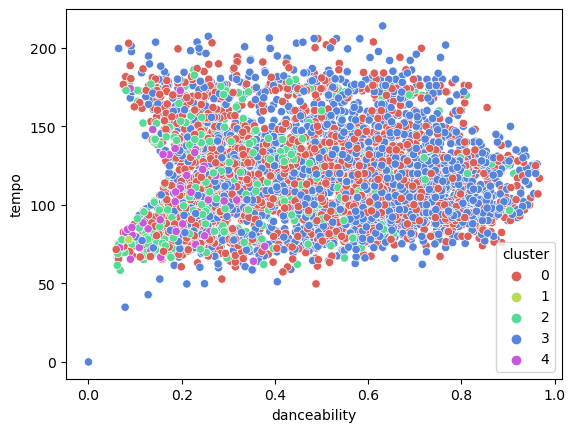

In [28]:
# 2-dimension scatterplot (bivariate)
sns.scatterplot(x='danceability',y='tempo',hue='cluster',palette=sns.color_palette("hls",clusters),data=df5k,legend="full")


In [29]:
# manual verficiation of features per cluster
df5k_v0.loc[df5k_v0['cluster']==0][['name','artist','html','cluster']].sample(5).sample(5)



,name,artist,html,cluster
4413,A Silent as the Grave ...,Wombbath,https://open.spotify.com/track/2y3xOvaPjZeUDfX...,0
1147,Born to Run ...,Bruce Springsteen,https://open.spotify.com/track/6hTcuIQa0sxrrBy...,0
2078,"Liebestraum, S. 541, No. 3 ...",Franz Liszt,https://open.spotify.com/track/5kOXNkG9ZWAn69s...,0
3297,Se Siente Bien ...,Dragon & Caballero,https://open.spotify.com/track/52xtApt0X5IZpV8...,0
2045,Piano Sonata No. 14 (quasi una Fantasia) in C-...,Ludwig van Beethoven,https://open.spotify.com/track/7GAGE2KQ0I548pZ...,0


### Business questions

1. Are Spotify's audio features able to identify 'similar songs', as defined by humanly detectable criteria?
There are non-human detectable features that could be relevant to classification (bpm, acoustics, background beats)


2. Is K-Means a good method to create playlists?
Drawbacks of kmeans for classification use cases

### Observations
- k-means is a good start for preprocessing data with high number of dimensions
- further analysis of dimensions should be considered
- large clusters requires further subgrouping
- distinct clusters vs proportional subgrouping of distinct range of dimension 
- kmeans cannot create playlists due to its nature of grouping items using distance between tuples as a classification method
- its possible to create playlists with more sophisticated classification methods


